# Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import pickle

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../data/processed/happiness_dataset.csv")

In [3]:
#definir variables dependiente e independientes
features = ["gdp_per_capita", "social_support", "life_expectancy",
            "freedom", "generosity", "corruption"]

X = df[features]
y = df["happiness_score"]

print(f"X: {X.shape}")
print(f"y: {y.shape}")

X: (782, 6)
y: (782,)


In [4]:
# dividir en train y test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba:        {X_test.shape[0]} filas")

Entrenamiento: 547 filas
Prueba:        235 filas


In [5]:
# entrenar modelo
model = LinearRegression()
model.fit(X_train, y_train)

print(f"\nCoeficientes:")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"\nIntercepto: {model.intercept_:.4f}")


Coeficientes:
  gdp_per_capita: 1.0878
  social_support: 0.6292
  life_expectancy: 0.9739
  freedom: 1.6213
  generosity: 0.4048
  corruption: 1.0299

Intercepto: 2.2349


In [6]:
# Evaluar el modelo
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  0.4486
R²:   0.7266


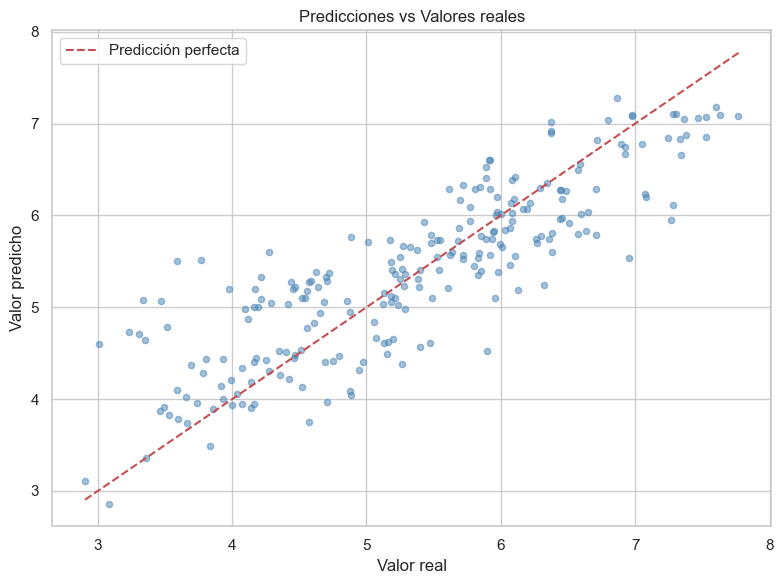

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue", s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         "r--", linewidth=1.5, label="Predicción perfecta")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Predicciones vs Valores reales")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
with open(f'../models/happiness_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('Modelo guardado en ../models/happiness_model.pkl')


Modelo guardado en ../models/happiness_model.pkl


## Check predictions

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import os

engine = create_engine(f"sqlite:///{"../database/predictions.db"}")

df_pred = pd.read_sql("SELECT * FROM predictions", engine)

print(f"Total de predicciones guardadas: {len(df_pred)}")
df_pred.head(10)

Total de predicciones guardadas: 3910


,id,country,year,actual,predicted,error
0,1,Switzerland,2015,7.587,7.1517,0.4353
1,2,Iceland,2015,7.561,6.7988,0.7622
2,3,Denmark,2015,7.527,7.0738,0.4532
3,4,Norway,2015,7.522,7.1239,0.3981
4,5,Canada,2015,7.427,6.9430,0.4840
5,6,Finland,2015,7.406,6.8949,0.5111
6,7,Netherlands,2015,7.378,6.8749,0.5031
7,8,Sweden,2015,7.364,7.0499,0.3141
8,9,New Zealand,2015,7.286,6.9809,0.3051
9,10,Australia,2015,7.284,7.0159,0.2681
